# 01 — EDA & Prétraitement
## Prédiction du Risque de Distribution des Médicaments en Tunisie

**Source :** DPM (dpm.tn) + PHCT (phct.com.tn)  
**Dataset :** 6053 médicaments · 28 features · Cible : `reaches_pharmacy`

---

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
SEED = 42
print('Imports OK ✓')

Imports OK ✓


## 2. Définition du Problème

### Objectif Business
28% des médicaments autorisés en Tunisie ne sont jamais distribués en pharmacie.
Un laboratoire qui soumet un nouveau médicament ne sait pas s'il sera commercialisé.

### Objectif Technique
Construire un modèle de **classification binaire supervisée** qui prédit :
- `reaches_pharmacy = 1` → le médicament sera distribué en pharmacie
- `reaches_pharmacy = 0` → le médicament ne sera jamais distribué

### Pipeline
```
Collecte (Scraping) → EDA → Prétraitement → Feature Engineering
→ Modélisation → Évaluation → Interprétation
```

## 3. Chargement du Dataset

In [2]:
df = pd.read_csv('ml_dataset.csv')
df = df.rename(columns={'is_available': 'reaches_pharmacy'})
print(f'Shape : {df.shape[0]} lignes × {df.shape[1]} colonnes')
df.head(5)

Shape : 6059 lignes × 28 colonnes


,nom,dci,laboratoire,amm,reaches_pharmacy,classe,sous_classe,forme,gp_status,veic,...,indications_len,nb_indications,est_generique,est_biosimilaire,est_injectable,est_chronique,indications,dosage,presentation,date_amm
0,5-FLUOROURACIL,FLUOROURACILE,EBEWE Pharma,6943091H,0,ANTINEOPLASIQUES ET IMMUNOMODULATEURS,ANTINEOPLASIQUES,Solution injectable,Générique,Vital,...,250,10,1,0,1,0,- Adénocarcinomes digestifs évolués; - Cancers...,250 MG,B/5/5ML,2001-01-20
1,5-FLUOROURACILE EBEWE,FLUOROURACILE,EBEWE Pharma,6943093H,0,ANTINEOPLASIQUES ET IMMUNOMODULATEURS,ANTINEOPLASIQUES,Solution injectable pour perfusion,Générique,Vital,...,250,10,1,0,1,0,- Adénocarcinomes digestifs évolués; - Cancers...,1000 mg/20 ml,B/1/20 ml,2012-04-30
2,5-FLUOROURACILE EBEWE,FLUOROURACILE,EBEWE Pharma,6943092H,0,ANTINEOPLASIQUES ET IMMUNOMODULATEURS,ANTINEOPLASIQUES,Solution injectable pour perfusion,Générique,Vital,...,250,10,1,0,1,0,- Adénocarcinomes digestifs évolués; - Cancers...,500 mg/10 ml,B/5/10 ml,2012-04-30
3,ABBOTICINE,ERYTHROMYCINE,ADWYA,9043061,1,ANTIINFECTIEUX GENERAUX A USAGE SYSTEMIQUE,ANTIBACTERIENS (USAGE SYSTEMIQUE),Poudre pour suspension orale,Princeps,Essentiel,...,250,1,0,0,0,0,INFECTIONS DUES AUX GERMES SENSIBLES NOTAMMENT...,200 MG,FL/60ML,1990-12-19
4,ABEVMY,BEVACIZUMAB,MYLAN PHARMACEUTICALS PRIVATE LIMITED,20343022H,0,ANTINEOPLASIQUES ET IMMUNOMODULATEURS,ANTINEOPLASIQUES,Solution à diluer pour perfusion,Biosimilaire,Vital,...,250,5,0,1,1,0,Cancer métastatique du colon ou du rectum - Ab...,400 mg(25mg/ml),B/1FL/16ml,2021-09-06


## 4. Analyse Exploratoire des Données (EDA)

### 4.1 Statistiques descriptives

In [3]:
print('=== Types de données ===')
print(df.dtypes)
print('\n=== Statistiques descriptives ===')
df.describe().round(2)

=== Types de données ===
nom                            str
dci                            str
laboratoire                    str
amm                            str
reaches_pharmacy             int64
classe                         str
sous_classe                    str
forme                          str
gp_status                      str
veic                           str
tableau                        str
nb_fabricants_dci            int64
hhi_dci                    float64
nb_amm_dci                   int64
nb_presentations_dci         int64
nb_dci_sous_classe           int64
anciennete_amm             float64
duree_conservation_mois    float64
indications_len              int64
nb_indications               int64
est_generique                int64
est_biosimilaire             int64
est_injectable               int64
est_chronique                int64
indications                    str
dosage                         str
presentation                   str
date_amm                      

,reaches_pharmacy,nb_fabricants_dci,hhi_dci,nb_amm_dci,nb_presentations_dci,nb_dci_sous_classe,anciennete_amm,duree_conservation_mois,indications_len,nb_indications,est_generique,est_biosimilaire,est_injectable,est_chronique
count,6059.00,6059.00,6059.00,6059.00,6059.00,6059.00,6059.00,6059.00,6059.00,6059.00,6059.00,6059.00,6059.00,6059.00
mean,0.72,6.08,0.36,19.53,7.46,27.46,14.81,30.93,205.64,2.49,0.69,0.00,0.23,0.53
std,0.45,4.51,0.30,20.24,7.72,19.43,8.52,9.26,65.58,2.10,0.46,0.07,0.42,0.50
min,0.00,1.00,0.08,1.00,1.00,1.00,2.10,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,2.00,0.14,5.00,2.00,13.00,8.00,24.00,165.00,1.00,0.00,0.00,0.00,0.00
50%,1.00,5.00,0.25,13.00,5.00,22.00,13.00,24.00,249.00,2.00,1.00,0.00,0.00,1.00
75%,1.00,9.00,0.50,26.00,10.00,33.00,20.40,36.00,250.00,3.00,1.00,0.00,0.00,1.00
max,1.00,20.00,1.00,87.00,42.00,78.00,38.50,60.00,250.00,19.00,1.00,1.00,1.00,1.00


### 4.2 Variable Cible

reaches_pharmacy
1    4386
0    1673
Name: count, dtype: int64

Taux distribué     : 72.4%
Taux non distribué : 27.6%


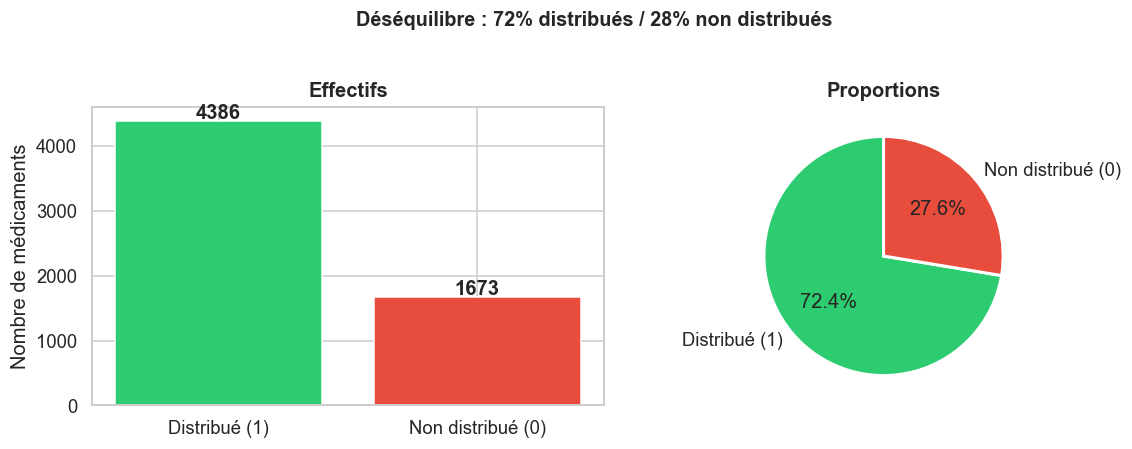

In [4]:
counts = df['reaches_pharmacy'].value_counts()
print(counts)
print(f'\nTaux distribué     : {df["reaches_pharmacy"].mean()*100:.1f}%')
print(f'Taux non distribué : {(1-df["reaches_pharmacy"].mean())*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = ['Distribué (1)', 'Non distribué (0)']
axes[0].bar(labels, counts.values, color=['#2ecc71','#e74c3c'], edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+30, str(v), ha='center', fontweight='bold')
axes[0].set_title('Effectifs', fontweight='bold')
axes[0].set_ylabel('Nombre de médicaments')
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proportions', fontweight='bold')
plt.suptitle('Déséquilibre : 72% distribués / 28% non distribués',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Identification des Valeurs Manquantes

              Nombre  Pourcentage (%)
dosage           545             8.99
veic              63             1.04
indications        8             0.13
presentation       5             0.08
dci                1             0.02


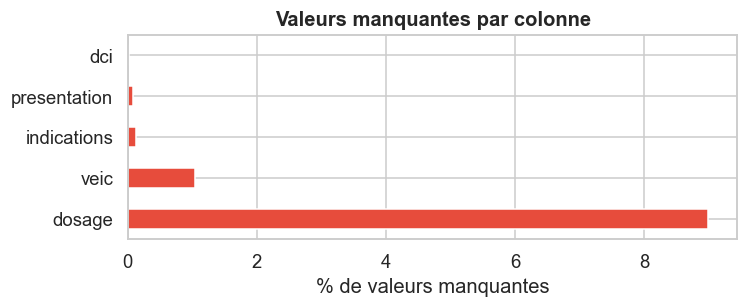

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Nombre': missing, 'Pourcentage (%)': missing_pct}))

fig, ax = plt.subplots(figsize=(7, 3))
missing_pct.plot(kind='barh', ax=ax, color='#e74c3c')
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Valeurs manquantes par colonne', fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 Visualisations — Variables Catégorielles

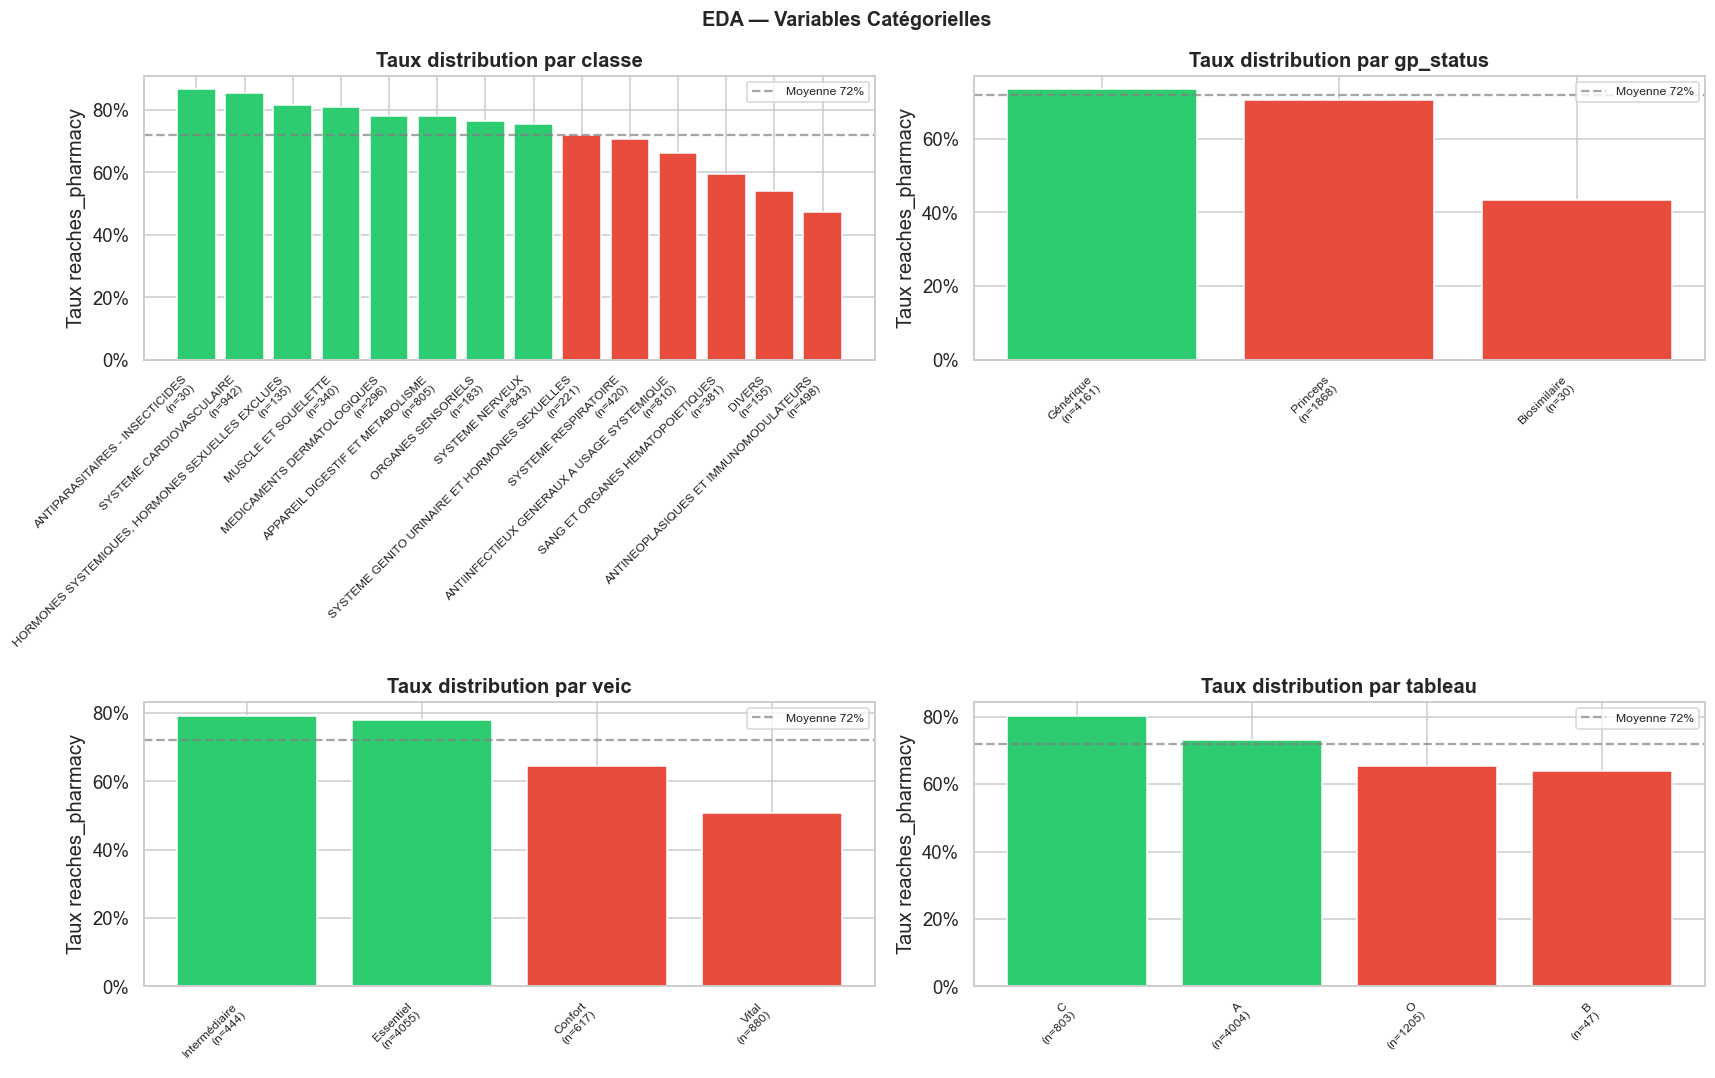

In [6]:
cat_cols = ['classe', 'gp_status', 'veic', 'tableau']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    rate  = df.groupby(col)['reaches_pharmacy'].mean().sort_values(ascending=False)
    count = df[col].value_counts()
    colors = ['#2ecc71' if v >= 0.72 else '#e74c3c' for v in rate.values]
    axes[i].bar(range(len(rate)), rate.values, color=colors, edgecolor='white')
    axes[i].axhline(y=0.72, color='gray', linestyle='--', alpha=0.7, label='Moyenne 72%')
    axes[i].set_xticks(range(len(rate)))
    axes[i].set_xticklabels(
        [f'{v}\n(n={count.get(v,0)})' for v in rate.index],
        rotation=45, ha='right', fontsize=8)
    axes[i].set_title(f'Taux distribution par {col}', fontweight='bold')
    axes[i].set_ylabel('Taux reaches_pharmacy')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    axes[i].legend(fontsize=8)
plt.suptitle('EDA — Variables Catégorielles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 Visualisations — Variables Numériques

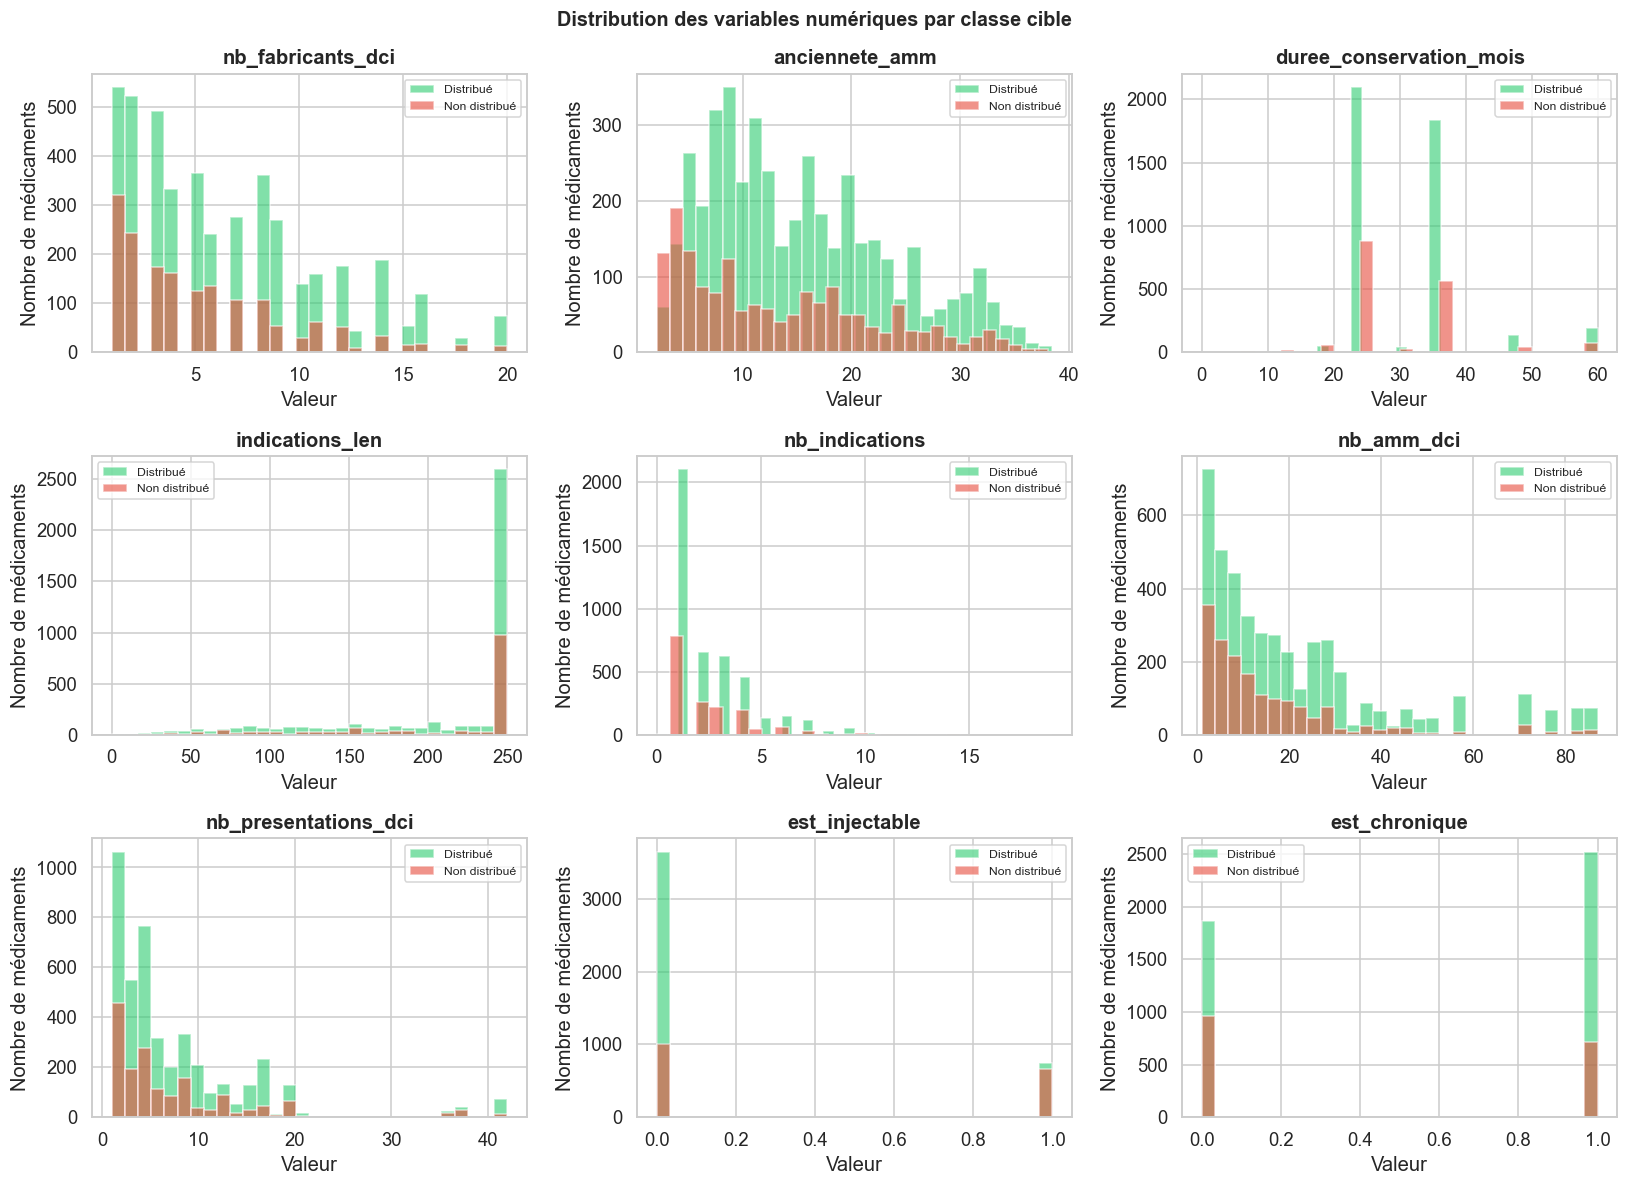

In [7]:
num_cols = ['nb_fabricants_dci','anciennete_amm','duree_conservation_mois',
            'indications_len','nb_indications','nb_amm_dci',
            'nb_presentations_dci','est_injectable','est_chronique']
num_cols = [c for c in num_cols if c in df.columns]
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    df[df['reaches_pharmacy']==1][col].hist(
        ax=axes[i], bins=30, alpha=0.6, color='#2ecc71', label='Distribué')
    df[df['reaches_pharmacy']==0][col].hist(
        ax=axes[i], bins=30, alpha=0.6, color='#e74c3c', label='Non distribué')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Nombre de médicaments')
    axes[i].legend(fontsize=8)
plt.suptitle('Distribution des variables numériques par classe cible',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.6 Matrice de Corrélation

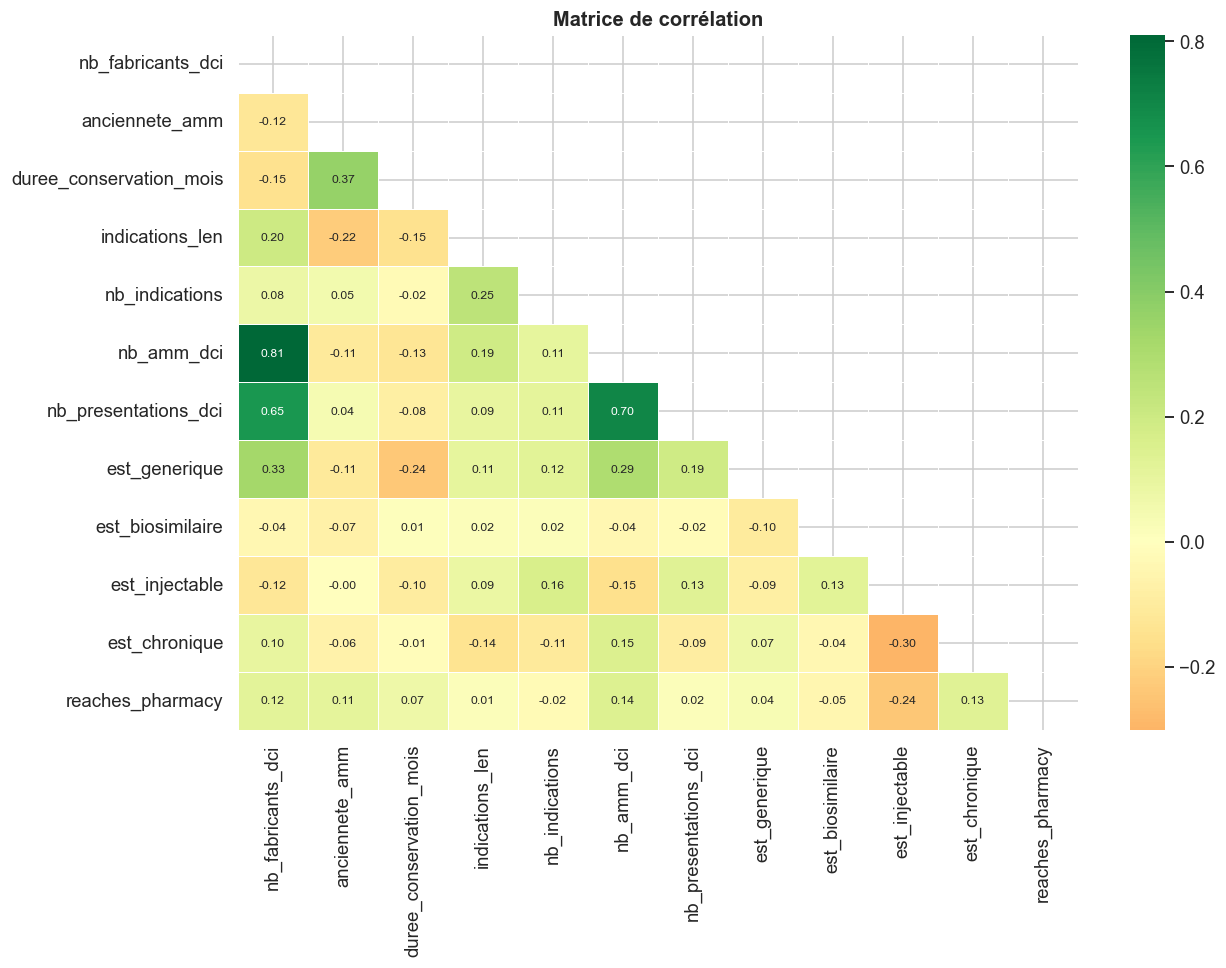

=== Corrélations avec reaches_pharmacy ===
est_injectable            -0.243
nb_amm_dci                 0.141
est_chronique              0.132
nb_fabricants_dci          0.118
anciennete_amm             0.111
duree_conservation_mois    0.074
est_biosimilaire          -0.046
est_generique              0.037
nb_indications            -0.024
nb_presentations_dci       0.017
indications_len            0.013
Name: reaches_pharmacy, dtype: float64


In [8]:
num_features = ['nb_fabricants_dci','anciennete_amm','duree_conservation_mois',
                'indications_len','nb_indications','nb_amm_dci',
                'nb_presentations_dci','est_generique','est_biosimilaire',
                'est_injectable','est_chronique','reaches_pharmacy']
num_features = [c for c in num_features if c in df.columns]
corr = df[num_features].corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Matrice de corrélation', fontweight='bold')
plt.tight_layout()
plt.show()
print('=== Corrélations avec reaches_pharmacy ===')
print(corr['reaches_pharmacy'].drop('reaches_pharmacy')
      .sort_values(key=abs, ascending=False).round(3))

## 5. Prétraitement des Données

### 5.1 Nettoyage — Doublons, NaN, Colonnes inutiles

In [9]:
# Doublons
print(f'Doublons : {df.duplicated().sum()}')
df = df.drop_duplicates().reset_index(drop=True)

# Nettoyage texte
cols_texte = ['nom','dci','laboratoire','classe','sous_classe','forme',
              'gp_status','veic','tableau','indications','dosage','presentation']
for col in cols_texte:
    if col in df.columns:
        df[col] = df[col].str.strip()
df['classe']      = df['classe'].str.upper().str.strip()
df['sous_classe'] = df['sous_classe'].str.upper().str.strip()

# Imputation NaN
df['dci']         = df['dci'].fillna('INCONNU')
df['veic']        = df['veic'].fillna(df['veic'].mode()[0])
df['indications'] = df['indications'].fillna('')
df['presentation']= df['presentation'].fillna('Non specifie')
df['dosage']      = df['dosage'].fillna('Non specifie')
df['date_amm']    = pd.to_datetime(df['date_amm'], errors='coerce')

# Suppression colonnes inutiles
# anciennete_amm, indications_len, nb_indications existent déjà dans le dataset
cols_drop = ['amm','hhi_dci','nb_dci_sous_classe','nom','indications','date_amm']
df = df.drop(columns=[c for c in cols_drop if c in df.columns])

# Nettoyage dosage et présentation
df['dosage_valeur'] = df['dosage'].str.extract(r'(\d+\.?\d*)').astype(float)
df['dosage_valeur'] = df['dosage_valeur'].fillna(df['dosage_valeur'].median())
def clean_unite(u):
    u = str(u).upper()
    if 'MG/ML' in u: return 'mg_ml'
    if 'MCG' in u or 'MICRO' in u: return 'mcg'
    if 'MG' in u: return 'mg'
    if 'UI' in u: return 'UI'
    if 'GR' in u or 'G/' in u: return 'gr'
    if '%' in u: return 'pct'
    return 'autre'
df['dosage_unite'] = (
    df['dosage'].str.extract(r'[\d\.]+\s*([a-zA-Z/%]+)').fillna('autre')
    .iloc[:,0].apply(clean_unite))
df = df.drop(columns=['dosage'])
def clean_pres(p):
    p = str(p).upper()
    if p.startswith('T/') or 'TUB' in p: return 'tube'
    if 'FL/' in p or 'FLAC' in p: return 'flacon'
    if p.startswith('B/'): return 'boite'
    return 'autre'
df['presentation_type'] = df['presentation'].apply(clean_pres)
df['presentation_qte']  = df['presentation'].str.extract(r'(\d+)').astype(float)
df['presentation_qte']  = df['presentation_qte'].fillna(df['presentation_qte'].median())
df = df.drop(columns=['presentation'])
print(f'Shape après nettoyage : {df.shape}')
print(f'NaN restants : {df.isnull().sum().sum()}')

Doublons : 6
Shape après nettoyage : (6053, 24)
NaN restants : 0


### 5.2 Encodage des Variables Catégorielles

> ⚠️ **Exception technique** : les features `vital_et_injectable` et `monopole`
> sont créées ICI, avant l'encodage, car elles utilisent les valeurs texte
> originales (`veic == 'Vital'`). Après encodage, cette condition serait fausse.
> Ce point sera détaillé dans la section Feature Engineering.

In [10]:
# ── Création features engineering AVANT encodage (nécessité technique) ──────
df['vital_et_injectable'] = (
    (df['veic'] == 'Vital') & (df['est_injectable'] == 1)
).astype(int)
df['monopole'] = (df['nb_fabricants_dci'] == 1).astype(int)
print('Features créées avant encodage ✓')

# ── Encodage ────────────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

# Ordinal : veic
veic_map = {'Confort':0,'Intermédiaire':1,'Essentiel':2,'Vital':3}
df['veic_enc'] = df['veic'].map(veic_map).fillna(4).astype(int)
df = df.drop(columns=['veic'])

# One-Hot : gp_status
gp_dummies = pd.get_dummies(df['gp_status'], prefix='gp', dtype=int)
df = pd.concat([df, gp_dummies], axis=1).drop(columns=['gp_status'])

# Label : haute cardinalité
le = LabelEncoder()
cols_label = ['dci','laboratoire','classe','sous_classe',
              'forme','tableau','dosage_unite','presentation_type']
for col in cols_label:
    if col in df.columns:
        df[col+'_enc'] = le.fit_transform(df[col].astype(str))
        df = df.drop(columns=[col])

cols = [c for c in df.columns if c != 'reaches_pharmacy']
df   = df[cols + ['reaches_pharmacy']]
print(f'Shape après encodage : {df.shape}')

Features créées avant encodage ✓
Shape après encodage : (6053, 28)


### 5.3 Normalisation — StandardScaler

> ⚠️ Le split est effectué ici pour respecter la règle anti data leakage :
> le scaler doit être fitté **uniquement sur le train**.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler

X = df.drop(columns=['reaches_pharmacy'])
y = df['reaches_pharmacy']

# Split avant normalisation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')

# Feature ratio_generique après split (anti data leakage)
dci_total   = X_train.groupby('dci_enc')['est_generique'].count()
dci_generiq = X_train.groupby('dci_enc')['est_generique'].sum()
ratio_gen   = (dci_generiq / dci_total).fillna(0)
X_train = X_train.copy()
X_test  = X_test.copy()
X_train['ratio_generique'] = X_train['dci_enc'].map(ratio_gen).fillna(0)
X_test['ratio_generique']  = X_test['dci_enc'].map(ratio_gen).fillna(0)

# Normalisation
cols_norm = ['nb_fabricants_dci','nb_amm_dci','nb_presentations_dci',
             'anciennete_amm','duree_conservation_mois',
             'indications_len','nb_indications','dosage_valeur',
             'presentation_qte','dci_enc','laboratoire_enc','classe_enc',
             'sous_classe_enc','forme_enc','tableau_enc','veic_enc',
             'ratio_generique']
cols_norm = [c for c in cols_norm if c in X_train.columns]

scaler = StandardScaler()
X_train[cols_norm] = scaler.fit_transform(X_train[cols_norm])
X_test[cols_norm]  = scaler.transform(X_test[cols_norm])
print(f'Normalisation ✓ sur {len(cols_norm)} colonnes')

Train : (4842, 27)  |  Test : (1211, 27)
Normalisation ✓ sur 17 colonnes


### 5.4 Gestion du Déséquilibre — SMOTE

> 72% distribués / 28% non distribués → SMOTE crée des observations
> synthétiques de la classe minoritaire (0) sur le train uniquement.

Avant SMOTE :
reaches_pharmacy
1    3505
0    1337
Name: count, dtype: int64

Après SMOTE :
reaches_pharmacy
0    3505
1    3505
Name: count, dtype: int64


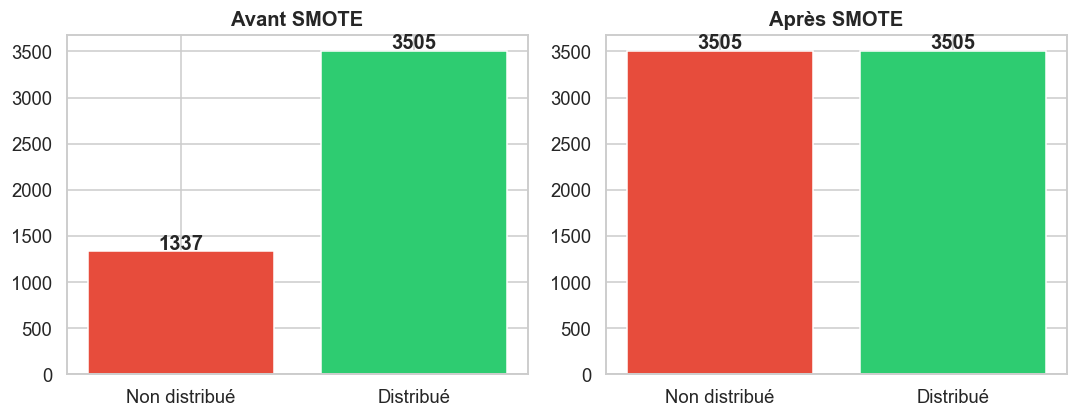

In [12]:
from imblearn.over_sampling import SMOTE

print('Avant SMOTE :')
print(y_train.value_counts())

smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('\nAprès SMOTE :')
print(y_train_sm.value_counts())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y_data, title) in zip(axes, [
    (y_train,    'Avant SMOTE'),
    (y_train_sm, 'Après SMOTE')
]):
    c = y_data.value_counts()
    ax.bar(['Non distribué','Distribué'],
           [c.get(0,0), c.get(1,0)],
           color=['#e74c3c','#2ecc71'], edgecolor='white')
    for i, v in enumerate([c.get(0,0), c.get(1,0)]):
        ax.text(i, v+20, str(v), ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Feature Engineering & Sélection

> Les features `vital_et_injectable` et `monopole` ont été créées en section 5.2
> avant l'encodage — nécessité technique. `ratio_generique` a été calculé
> après le split pour éviter le data leakage.

| Feature | Raison | Calculée où |
|---------|--------|-------------|
| `vital_et_injectable` | Médicale — hospitalier par nature | Avant encodage (section 5.2) |
| `monopole` | Commerciale — risque rupture | Avant encodage (section 5.2) |
| `ratio_generique` | Concurrentielle — marché saturé | Après split sur train (section 5.3) |

In [13]:
print('=== Résumé Feature Engineering ===')
print(f'vital_et_injectable : {X_train_sm["vital_et_injectable"].value_counts().to_dict()}')
print(f'monopole            : {X_train_sm["monopole"].value_counts().to_dict()}')
print(f'ratio_generique     : min={X_train_sm["ratio_generique"].min():.2f}, '
      f'max={X_train_sm["ratio_generique"].max():.2f}, '
      f'mean={X_train_sm["ratio_generique"].mean():.2f}')
print(f'\nFeatures totales    : {X_train_sm.shape[1]}')
print(f'X_train_sm shape    : {X_train_sm.shape}')
print(f'X_test shape        : {X_test.shape}')

=== Résumé Feature Engineering ===
vital_et_injectable : {0: 6088, 1: 922}
monopole            : {0: 6026, 1: 984}
ratio_generique     : min=-1.95, max=0.88, mean=-0.03

Features totales    : 28
X_train_sm shape    : (7010, 28)
X_test shape        : (1211, 28)


## 7. Résumé — Données prêtes pour la modélisation

In [ ]:
print('='*55)
print('         DONNÉES PRÊTES POUR LA MODÉLISATION')
print('='*55)
print(f'X_train_sm : {X_train_sm.shape}  (avec SMOTE)')
print(f'y_train_sm : {y_train_sm.shape}')
print(f'X_test     : {X_test.shape}  (données réelles)')
print(f'y_test     : {y_test.shape}')
print(f'\nNaN X_train_sm : {X_train_sm.isnull().sum().sum()}')
print(f'NaN X_test     : {X_test.isnull().sum().sum()}')
print(f'\nUtiliser X_train_sm / y_train_sm pour entraîner')
print(f'Utiliser X_test / y_test pour évaluer')

         DONNÉES PRÊTES POUR LA MODÉLISATION
X_train_sm : (7010, 28)  (avec SMOTE)
y_train_sm : (7010,)
X_test     : (1211, 28)  (données réelles)
y_test     : (1211,)

NaN X_train_sm : 0
NaN X_test     : 0

✅ Utiliser X_train_sm / y_train_sm pour entraîner
✅ Utiliser X_test / y_test pour évaluer


## 8. Sauvegarde des données pour le notebook 02

> On sauvegarde les variables dans des fichiers `.pkl` pour les
> réutiliser dans le notebook de modélisation sans tout recalculer.

In [15]:
import joblib
import os

# Sauvegarde des données pour le notebook 02
os.makedirs('data_ml', exist_ok=True)

joblib.dump(X_train_sm, 'data_ml/X_train_sm.pkl')
joblib.dump(y_train_sm, 'data_ml/y_train_sm.pkl')
joblib.dump(X_test,     'data_ml/X_test.pkl')
joblib.dump(y_test,     'data_ml/y_test.pkl')

print('✅ Données sauvegardées dans le dossier data_ml/')
print(f'   X_train_sm : {X_train_sm.shape}')
print(f'   y_train_sm : {y_train_sm.shape}')
print(f'   X_test     : {X_test.shape}')
print(f'   y_test     : {y_test.shape}')

✅ Données sauvegardées dans le dossier data_ml/
   X_train_sm : (7010, 28)
   y_train_sm : (7010,)
   X_test     : (1211, 28)
   y_test     : (1211,)


In [ ]:
import pickle
import os

print(" Sauvegarde des données dans Google Drive...")

  # Créer le dossier data_ml dans Drive
os.makedirs('/content/drive/MyDrive/data_ml', exist_ok=True)

  # Sauvegarder X_train_sm
with open('/content/drive/MyDrive/data_ml/X_train_sm.pkl', 'wb') as f:
      pickle.dump(X_train_sm, f)
print(" X_train_sm sauvegardé")

  # Sauvegarder y_train_sm
with open('/content/drive/MyDrive/data_ml/y_train_sm.pkl', 'wb') as f:
      pickle.dump(y_train_sm, f)
print(" y_train_sm sauvegardé")

  # Sauvegarder X_test
with open('/content/drive/MyDrive/data_ml/X_test.pkl', 'wb') as f:
      pickle.dump(X_test, f)
print(" X_test sauvegardé")

  # Sauvegarder y_test
with open('/content/drive/MyDrive/data_ml/y_test.pkl', 'wb') as f:
      pickle.dump(y_test, f)
print(" y_test sauvegardé")

print("\n TOUTES LES DONNÉES SONT SAUVEGARDÉES DANS GOOGLE DRIVE!")